In [62]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib widget
from scipy.signal import welch, detrend, csd, coherence, find_peaks
from scipy.linalg import svd
import os

plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['figure.figsize'] = (5, 4.5)
plt.rcParams['figure.dpi'] = 80
plt.rcParams.update({'font.size': 12}) 

In [63]:
# Obtener solo carpetas
carpetas = [carpeta for carpeta in os.listdir('.') if os.path.isdir(carpeta)]

# Mostrar carpetas
print('Carpetas de data:')
for i, carpeta in enumerate(carpetas):
    print(f'[{i}] --> {carpeta}')

Carpetas de data:
[0] --> DATA_CorreaOverland
[1] --> DATA_PuenteItata+Tren
[2] --> DATA_PuenteItata_ALL
[3] --> DATA_PuenteItata_Evento
[4] --> DATA_PuenteItata_Reposo
[5] --> Export_Artemis
[6] --> Modelos_TeklaStructures
[7] --> Registros


In [64]:
carpeta_data = carpetas[2]
print(f'Carpeta escogida: {carpeta_data}')

Carpeta escogida: DATA_PuenteItata_ALL


In [65]:
#data = [archivo for archivo in os.listdir('./DATA_CorreaOverland/') if archivo.endswith(".txt")]
data_all = [archivo for archivo in os.listdir(f'./{carpeta_data}/') if archivo.endswith(".txt")]
for i in range(len(data_all)):
    print('[{}]'.format(i),'-->', data_all[i])

[0] --> Proc_Excitacion_20260509_223448.txt
[1] --> Proc_Reposo_20260507_124913.txt
[2] --> Proc_Reposo_20260508_154628.txt
[3] --> Proc_Reposo_20260509_074822.txt
[4] --> Proc_Reposo_20260509_195552.txt
[5] --> Proc_Reposo_20260510_061349.txt
[6] --> Proc_Reposo_20260511_105419.txt
[7] --> Proc_Reposo_20260512_213724.txt
[8] --> Proc_Tren_20260502_092150.txt
[9] --> Proc_Tren_20260502_161609.txt
[10] --> Proc_Tren_20260504_113353.txt
[11] --> Proc_Tren_20260504_142017.txt
[12] --> Proc_Tren_20260504_164914.txt
[13] --> Proc_Tren_20260504_190842.txt
[14] --> Proc_Tren_20260505_042815.txt
[15] --> Proc_Tren_20260505_095032.txt
[16] --> Proc_Tren_20260505_113710.txt
[17] --> Proc_Tren_20260505_141516.txt
[18] --> Proc_Tren_20260505_161238.txt
[19] --> Proc_Tren_20260505_164918.txt
[20] --> Proc_Tren_20260505_191956.txt
[21] --> Proc_Tren_20260506_053130.txt
[22] --> Proc_Tren_20260506_134319.txt
[23] --> Proc_Tren_20260506_155242.txt


In [66]:
data = data_all[8]
name_data = data[:-4]
print(f'Registro escogido: {data}')
print(f'Nombre data: {name_data}')

Registro escogido: Proc_Tren_20260502_092150.txt
Nombre data: Proc_Tren_20260502_092150


In [67]:
#df = pd.read_table('./DATA_CorreaOverland/{}'.format(enss), decimal=".")
df = pd.read_table(f'./{carpeta_data}/{data}', decimal=".")
#df.columns = ['Tiempo [s]', 'A1', 'A2', 'A3', 'Hammer', 'Comment']
#df.drop(['Comment'], axis=1, inplace=True)
#df = df.drop(columns=['Comment'])
display(df)

,Time,Ac00_L,Ac00_T,Ac00_V,Ac01_L,Ac01_T,Ac01_V,Ac02_L,Ac02_T,Ac02_V,Ac03_L,Ac03_T,Ac03_V,Ac05_L,Ac05_T,Ac05_V
0,02-May-2026 09:21:00,0.000048,0.000078,-0.000200,0.000034,0.000075,-0.000309,0.000073,-0.000872,-0.000518,0.000302,-0.000289,0.000208,-0.000363,0.000977,0.000047
1,02-May-2026 09:21:00,-0.000020,0.000054,-0.000123,0.000145,-0.000255,-0.000334,0.000176,-0.000712,-0.000415,0.000201,-0.000474,0.000104,0.000142,-0.000042,-0.000016
2,02-May-2026 09:21:00,0.000111,0.000097,0.000059,0.000156,-0.000156,-0.000361,0.000160,0.000160,-0.000066,0.000018,-0.000207,-0.000079,-0.000132,-0.000216,0.000206
3,02-May-2026 09:21:00,0.000055,-0.000033,-0.000092,-0.000025,0.000374,-0.000138,0.000102,0.000722,-0.000271,-0.000246,0.000271,-0.000054,-0.000193,-0.000028,-0.000357
4,02-May-2026 09:21:00,-0.000121,0.000010,-0.000002,-0.000187,0.000218,0.000156,0.000041,0.000240,-0.000019,-0.000394,0.000470,-0.000126,-0.000094,-0.000433,-0.000334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24996,02-May-2026 09:22:40,0.000191,0.000135,0.000068,-0.000023,0.000099,0.000066,0.000180,-0.000013,0.000079,0.000105,-0.000101,0.000330,0.000170,-0.000498,0.000138
24997,02-May-2026 09:22:40,-0.000144,-0.000138,0.000111,-0.000140,0.000080,0.000035,-0.000121,-0.000154,0.000046,0.000002,0.000141,0.000206,0.000256,-0.000425,0.000226
24998,02-May-2026 09:22:40,-0.000078,-0.000369,-0.000123,-0.000131,0.000117,-0.000030,-0.000179,-0.000230,0.000321,0.000009,0.000368,0.000365,0.000129,-0.000715,0.000341
24999,02-May-2026 09:22:40,0.000035,-0.000080,-0.000068,-0.000301,-0.000224,0.000099,-0.000409,-0.000277,0.000308,-0.000170,0.000527,0.000368,0.000146,-0.000711,0.000423


In [68]:
# Tiempo total
t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds()
# Cantidad de muestras
N = len(df)
# Frecuencia de muestreo
fs = N / t_total
print(f'Cantidad de datos:\t{N}')
print(f'Frecuencia de muestreo:\t{fs:.4f} Hz')

Cantidad de datos:	25001
Frecuencia de muestreo:	250.0100 Hz


In [69]:
canales = list(df.columns[1:])

# Revisar datos faltantes
# print("Datos faltantes por canal:")
# print(df[canales].isna().sum())

# Estadística básica
resumen = df[canales].describe().T
resumen["rms"] = np.sqrt(np.mean(df[canales]**2, axis=0))
resumen["media_abs"] = df[canales].mean().abs()
resumen["max_abs"] = df[canales].abs().max()

resumen

,count,mean,std,min,25%,50%,75%,max,rms,media_abs,max_abs
Ac00_L,25001.0,-0.000002,0.003261,-0.046032,-0.000185,0.0,0.000181,0.051045,0.003261,0.000002,0.051045
Ac00_T,25001.0,-0.000005,0.001334,-0.027364,-0.000127,0.0,0.000124,0.023293,0.001334,0.000005,0.027364
Ac00_V,25001.0,-0.000003,0.002462,-0.049338,-0.000161,0.0,0.000161,0.040418,0.002462,0.000003,0.049338
Ac01_L,25001.0,0.000033,0.011396,-0.134523,-0.001201,0.0,0.001228,0.234967,0.011396,0.000033,0.234967
Ac01_T,25001.0,0.000071,0.038832,-0.802068,-0.000739,0.0,0.000721,0.768598,0.038831,0.000071,0.802068
Ac01_V,25001.0,0.000100,0.030015,-0.608576,-0.000760,0.0,0.000767,0.990358,0.030014,0.000100,0.990358
Ac02_L,25001.0,0.000167,0.010684,-0.141461,-0.001100,0.0,0.001144,0.244039,0.010685,0.000167,0.244039
Ac02_T,25001.0,-0.000019,0.045405,-1.136639,-0.000881,0.0,0.000892,0.918271,0.045404,0.000019,1.136639
Ac02_V,25001.0,0.000500,0.033611,-0.878206,-0.001054,0.0,0.001132,0.560061,0.033614,0.000500,0.878206
Ac03_L,25001.0,0.000003,0.009969,-0.228000,-0.001075,0.0,0.001082,0.166195,0.009969,0.000003,0.228000


In [70]:
def resumen_calidad_ventana(df, fs=fs, nombre_ventana=data[:-4]):
    """
    Calcula métricas de control de calidad para una ventana de aceleración.
    
    df : DataFrame con columnas tipo Ac00_L, Ac00_T, Ac00_V, etc.
    fs : frecuencia de muestreo [Hz]
    """

    resultados = []

    # Buscar columnas de aceleración
    cols_acc = [c for c in df.columns if c.startswith("Ac")]

    for col in cols_acc:

        x = df[col].dropna().values
        n = len(x)

        if n == 0:
            continue

        duracion = n / fs

        media = np.mean(x)
        std = np.std(x)
        rms = np.sqrt(np.mean(x**2))
        max_abs = np.max(np.abs(x))
        minimo = np.min(x)
        maximo = np.max(x)

        # Crest factor: indica presencia de impulsos/golpes
        crest_factor = max_abs / rms if rms != 0 else np.nan

        # Kurtosis: alta kurtosis indica eventos impulsivos
        kurtosis = np.mean(((x - media) / std)**4) if std != 0 else np.nan

        # Offset relativo
        offset_rel = abs(media) / rms if rms != 0 else np.nan

        # Porcentaje de datos faltantes respecto al largo original
        n_nan = df[col].isna().sum()
        porc_nan = 100 * n_nan / len(df[col])

        resultados.append({
            "ventana": nombre_ventana,
            "canal": col,
            "n_datos": n,
            "duracion_s": duracion,
            "fs_Hz": fs,
            "media": media,
            "std": std,
            "rms": rms,
            "max_abs": max_abs,
            "min": minimo,
            "max": maximo,
            "crest_factor": crest_factor,
            "kurtosis": kurtosis,
            "offset_rel": offset_rel,
            "n_nan": n_nan,
            "porc_nan": porc_nan
        })

    return pd.DataFrame(resultados)

In [71]:
resumen_ventana = resumen_calidad_ventana(df=df,fs=fs,nombre_ventana=name_data)
resumen_ventana

,ventana,canal,n_datos,duracion_s,fs_Hz,media,std,rms,max_abs,min,max,crest_factor,kurtosis,offset_rel,n_nan,porc_nan
0,Proc_Tren_20260502_092150,Ac00_L,25001,100.0,250.01,-0.000002,0.003261,0.003261,0.051045,-0.046032,0.051045,15.655207,54.861905,0.000710,0,0.0
1,Proc_Tren_20260502_092150,Ac00_T,25001,100.0,250.01,-0.000005,0.001334,0.001334,0.027364,-0.027364,0.023293,20.518115,61.054659,0.004121,0,0.0
2,Proc_Tren_20260502_092150,Ac00_V,25001,100.0,250.01,-0.000003,0.002462,0.002462,0.049338,-0.049338,0.040418,20.039017,67.980794,0.001324,0,0.0
3,Proc_Tren_20260502_092150,Ac01_L,25001,100.0,250.01,0.000033,0.011396,0.011396,0.234967,-0.134523,0.234967,20.617815,40.974166,0.002933,0,0.0
4,Proc_Tren_20260502_092150,Ac01_T,25001,100.0,250.01,0.000071,0.038831,0.038831,0.802068,-0.802068,0.768598,20.655221,93.491500,0.001837,0,0.0
5,Proc_Tren_20260502_092150,Ac01_V,25001,100.0,250.01,0.000100,0.030014,0.030014,0.990358,-0.608576,0.990358,32.996071,119.409804,0.003330,0,0.0
6,Proc_Tren_20260502_092150,Ac02_L,25001,100.0,250.01,0.000167,0.010684,0.010685,0.244039,-0.141461,0.244039,22.838485,62.004432,0.015672,0,0.0
7,Proc_Tren_20260502_092150,Ac02_T,25001,100.0,250.01,-0.000019,0.045404,0.045404,1.136639,-1.136639,0.918271,25.033850,90.165727,0.000411,0,0.0
8,Proc_Tren_20260502_092150,Ac02_V,25001,100.0,250.01,0.000500,0.033610,0.033614,0.878206,-0.878206,0.560061,26.126311,80.327048,0.014868,0,0.0
9,Proc_Tren_20260502_092150,Ac03_L,25001,100.0,250.01,0.000003,0.009969,0.009969,0.228000,-0.228000,0.166195,22.871235,55.248840,0.000341,0,0.0


In [72]:
resumen_ventana["flag_offset"] = resumen_ventana["offset_rel"] > 0.10
resumen_ventana["flag_impulsiva"] = resumen_ventana["crest_factor"] > 6
resumen_ventana["flag_kurtosis_alta"] = resumen_ventana["kurtosis"] > 5
resumen_ventana["flag_nan"] = resumen_ventana["porc_nan"] > 0

In [73]:
resumen_ventana[
    resumen_ventana[[
        "flag_offset",
        "flag_impulsiva",
        "flag_kurtosis_alta",
        "flag_nan"
    ]].any(axis=1)
]

,ventana,canal,n_datos,duracion_s,fs_Hz,media,std,rms,max_abs,min,max,crest_factor,kurtosis,offset_rel,n_nan,porc_nan,flag_offset,flag_impulsiva,flag_kurtosis_alta,flag_nan
0,Proc_Tren_20260502_092150,Ac00_L,25001,100.0,250.01,-0.000002,0.003261,0.003261,0.051045,-0.046032,0.051045,15.655207,54.861905,0.000710,0,0.0,False,True,True,False
1,Proc_Tren_20260502_092150,Ac00_T,25001,100.0,250.01,-0.000005,0.001334,0.001334,0.027364,-0.027364,0.023293,20.518115,61.054659,0.004121,0,0.0,False,True,True,False
2,Proc_Tren_20260502_092150,Ac00_V,25001,100.0,250.01,-0.000003,0.002462,0.002462,0.049338,-0.049338,0.040418,20.039017,67.980794,0.001324,0,0.0,False,True,True,False
3,Proc_Tren_20260502_092150,Ac01_L,25001,100.0,250.01,0.000033,0.011396,0.011396,0.234967,-0.134523,0.234967,20.617815,40.974166,0.002933,0,0.0,False,True,True,False
4,Proc_Tren_20260502_092150,Ac01_T,25001,100.0,250.01,0.000071,0.038831,0.038831,0.802068,-0.802068,0.768598,20.655221,93.491500,0.001837,0,0.0,False,True,True,False
5,Proc_Tren_20260502_092150,Ac01_V,25001,100.0,250.01,0.000100,0.030014,0.030014,0.990358,-0.608576,0.990358,32.996071,119.409804,0.003330,0,0.0,False,True,True,False
6,Proc_Tren_20260502_092150,Ac02_L,25001,100.0,250.01,0.000167,0.010684,0.010685,0.244039,-0.141461,0.244039,22.838485,62.004432,0.015672,0,0.0,False,True,True,False
7,Proc_Tren_20260502_092150,Ac02_T,25001,100.0,250.01,-0.000019,0.045404,0.045404,1.136639,-1.136639,0.918271,25.033850,90.165727,0.000411,0,0.0,False,True,True,False
8,Proc_Tren_20260502_092150,Ac02_V,25001,100.0,250.01,0.000500,0.033610,0.033614,0.878206,-0.878206,0.560061,26.126311,80.327048,0.014868,0,0.0,False,True,True,False
9,Proc_Tren_20260502_092150,Ac03_L,25001,100.0,250.01,0.000003,0.009969,0.009969,0.228000,-0.228000,0.166195,22.871235,55.248840,0.000341,0,0.0,False,True,True,False


Y shape: (25001, 15)
N polos: 710


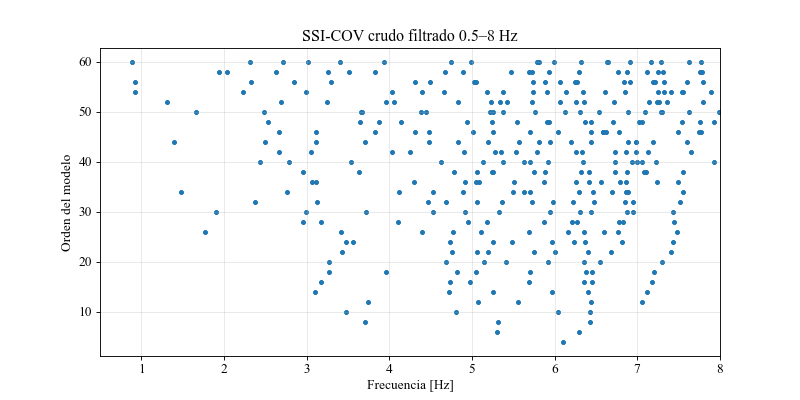

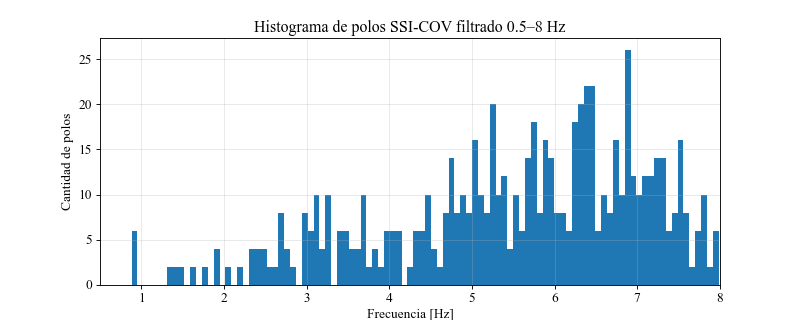

,freq_Hz,xi,order
701,0.881610,0.289131,60
700,0.881610,0.289131,60
568,0.926985,0.126753,54
569,0.926985,0.126753,54
609,0.928377,-0.090951,56
608,0.928377,-0.090951,56
517,1.309201,-0.004849,52
516,1.309201,-0.004849,52
378,1.393493,0.165741,44
379,1.393493,0.165741,44


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.linalg import svd, eig

# ============================================================
# 1) DATOS
# ============================================================

fs = 250.0
cols = list(df.columns[1:])   # omite primera columna si es tiempo/fecha

Y = df[cols].to_numpy(dtype=float)

# Quitar media y normalizar
Y = Y - np.mean(Y, axis=0)

std = np.std(Y, axis=0)
std[std == 0] = 1.0
Y = Y / std

print("Y shape:", Y.shape)  # esperado: (25001, 15)

# ============================================================
# 2) FILTRO PASA BANDA
# ============================================================

def bandpass(Y, fs, f1=0.5, f2=8.0, order=4):
    b, a = butter(order, [f1/(fs/2), f2/(fs/2)], btype="band")
    return filtfilt(b, a, Y, axis=0)

Y_filt = bandpass(Y, fs, f1=0.5, f2=8.0, order=4)

# ============================================================
# 3) SSI-COV CRUDO
# ============================================================

def ssi_cov_raw(Y, fs, br=20, orders=range(2, 61, 2), fmin=0.5, fmax=8.0):
    """
    SSI-COV básico/crudo.
    Y: matriz [n_muestras, n_canales]
    """

    n_samples, n_ch = Y.shape

    # Covarianzas
    R = []
    for k in range(2 * br + 1):
        if k == 0:
            Rk = (Y.T @ Y) / n_samples
        else:
            Rk = (Y[k:].T @ Y[:-k]) / (n_samples - k)
        R.append(Rk)

    # Matriz Toeplitz/Hankel de covarianzas
    H0 = np.zeros((br * n_ch, br * n_ch))

    for i in range(br):
        for j in range(br):
            H0[i*n_ch:(i+1)*n_ch, j*n_ch:(j+1)*n_ch] = R[i + j + 1]

    # SVD
    U, S, VT = svd(H0, full_matrices=False)

    all_freq = []
    all_xi = []
    all_order = []

    for order in orders:

        U1 = U[:, :order]
        S1 = np.diag(np.sqrt(S[:order]))

        # Observabilidad extendida
        O = U1 @ S1

        O_up = O[:-n_ch, :]
        O_down = O[n_ch:, :]

        # Matriz A discreta
        A = np.linalg.lstsq(O_up, O_down, rcond=None)[0]

        # Autovalores discretos
        mu, _ = eig(A)

        # Conversión a polos continuos
        lam = np.log(mu) * fs

        fn = np.abs(lam) / (2 * np.pi)
        xi = -np.real(lam) / np.abs(lam)

        mask = (
            np.isfinite(fn) &
            np.isfinite(xi) &
            (fn > fmin) &
            (fn < fmax) &
            (xi > -0.10) &
            (xi < 0.50)
        )

        all_freq.extend(fn[mask])
        all_xi.extend(xi[mask])
        all_order.extend([order] * np.sum(mask))

    return np.array(all_freq), np.array(all_xi), np.array(all_order)

# ============================================================
# 4) EJECUTAR SSI
# ============================================================

freq, xi, order = ssi_cov_raw(
    Y_filt,
    fs=fs,
    br=20,
    orders=range(2, 61, 2),
    fmin=0.5,
    fmax=8.0
)

print("N polos:", len(freq))

# ============================================================
# 5) DIAGRAMA DE POLOS
# ============================================================

plt.figure(figsize=(10,5))
plt.scatter(freq, order, s=10)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Orden del modelo")
plt.title("SSI-COV crudo filtrado 0.5–8 Hz")
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 8.0)
plt.show()

# ============================================================
# 6) HISTOGRAMA DE POLOS
# ============================================================

plt.figure(figsize=(10,4))
plt.hist(freq, bins=100)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Cantidad de polos")
plt.title("Histograma de polos SSI-COV filtrado 0.5–8 Hz")
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 8.0)
plt.show()

# ============================================================
# 7) TABLA RESUMEN
# ============================================================

import pandas as pd

df_ssi = pd.DataFrame({
    "freq_Hz": freq,
    "xi": xi,
    "order": order
}).sort_values("freq_Hz")

df_ssi.head(30)


Dirección L
Columnas: ['Ac00_L', 'Ac01_L', 'Ac02_L', 'Ac03_L', 'Ac05_L']
N polos: 444


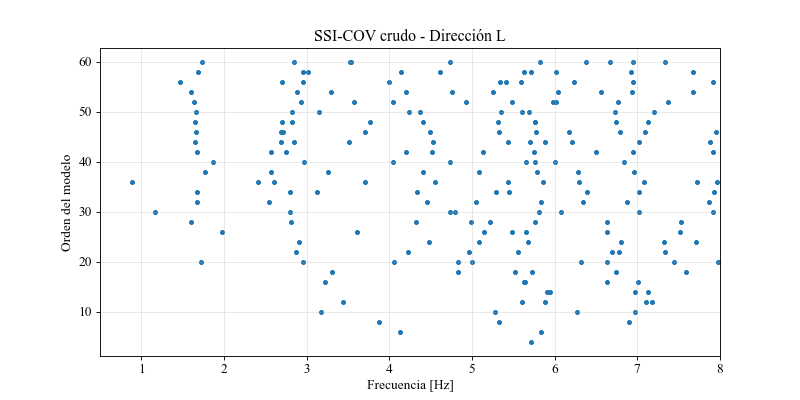

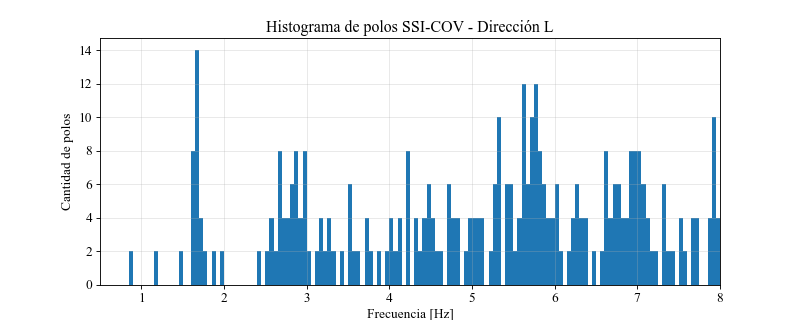

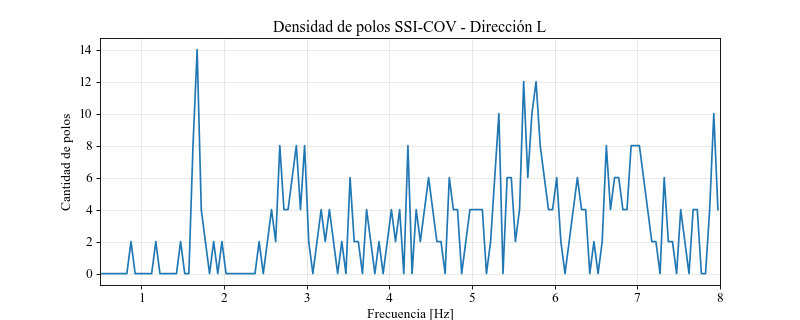


Dirección T
Columnas: ['Ac00_T', 'Ac01_T', 'Ac02_T', 'Ac03_T', 'Ac05_T']
N polos: 412


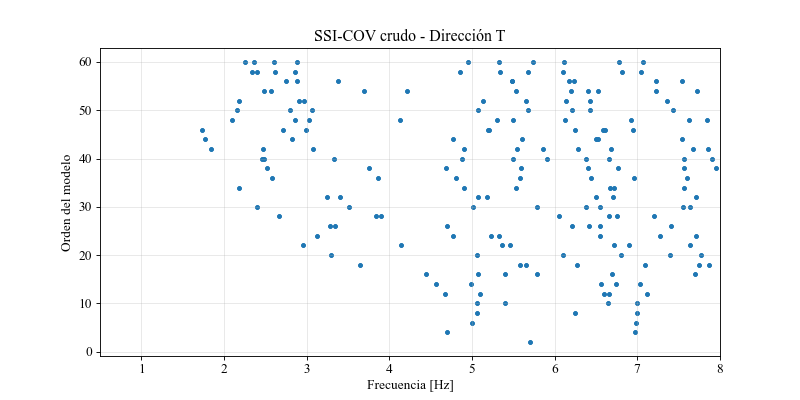

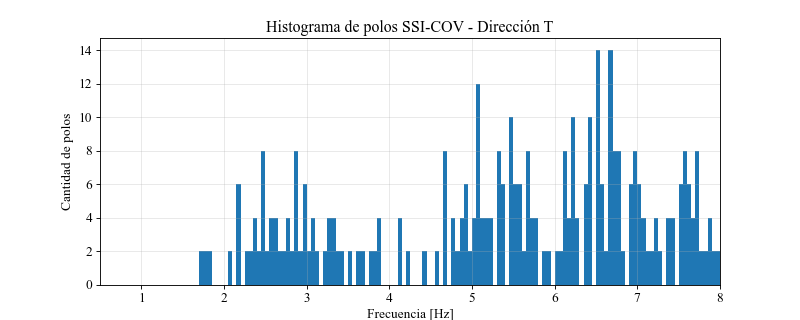

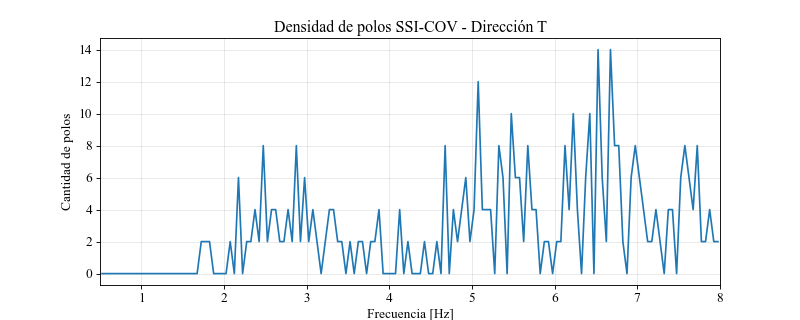


Dirección V
Columnas: ['Ac00_V', 'Ac01_V', 'Ac02_V', 'Ac03_V', 'Ac05_V']
N polos: 394


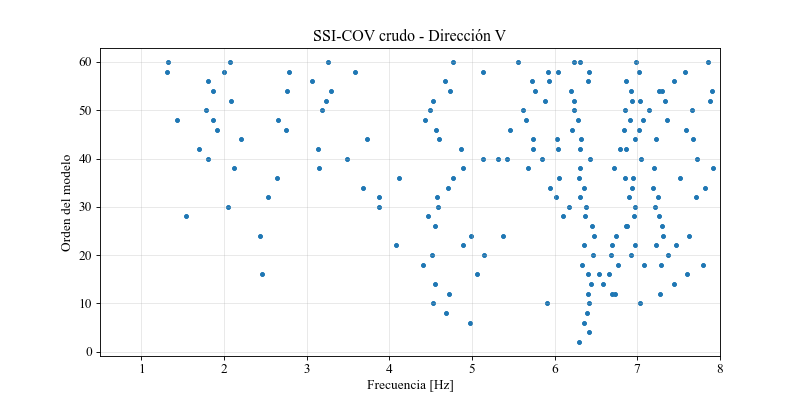

C:\Users\mihrs\AppData\Local\Temp\ipykernel_11192\3589116177.py:156: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


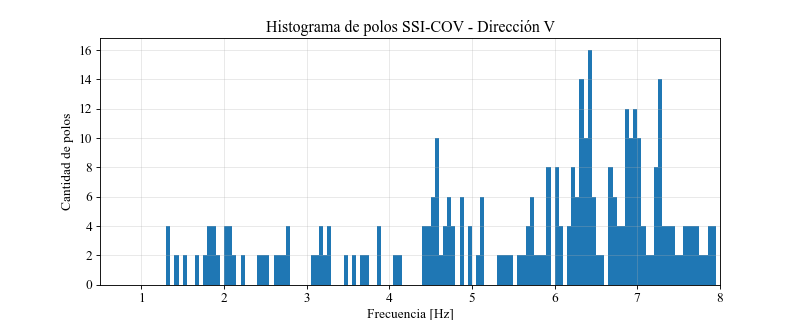

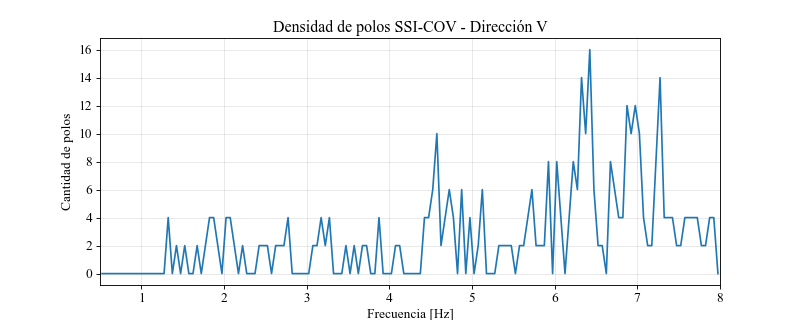


Resumen de polos SSI:


,direccion,freq_Hz,xi,order
0,L,0.885149,0.449185,36
1,L,0.885149,0.449185,36
2,L,1.162496,0.319748,30
3,L,1.162496,0.319748,30
4,L,1.470056,0.467851,56
5,L,1.470056,0.467851,56
6,L,1.601574,0.316850,54
7,L,1.601574,0.316850,54
8,L,1.604550,0.364075,28
9,L,1.604550,0.364075,28



Resumen histograma SSI:


,direccion,freq_center_Hz,n_polos
0,L,0.525,0
1,L,0.575,0
2,L,0.625,0
3,L,0.675,0
4,L,0.725,0
5,L,0.775,0
6,L,0.825,0
7,L,0.875,2
8,L,0.925,0
9,L,0.975,0


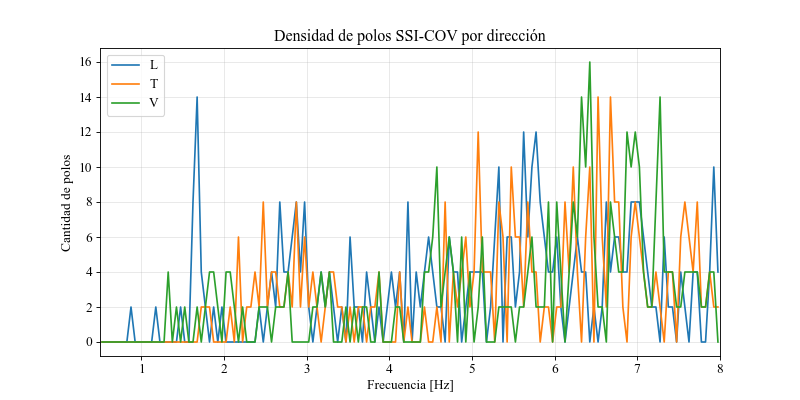

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from scipy.linalg import svd, eig

# ============================================================
# CONFIGURACIÓN
# ============================================================

fs = 250.0

fmin = 0.5
fmax = 8.0

br = 20
orders = range(2, 61, 2)

bin_width = 0.05

# ============================================================
# FUNCIONES
# ============================================================

def preparar_data(df, cols):
    Y = df[cols].to_numpy(dtype=float)

    # quitar media
    Y = Y - np.mean(Y, axis=0)

    # normalizar por canal
    std = np.std(Y, axis=0)
    std[std == 0] = 1.0
    Y = Y / std

    return Y


def bandpass(Y, fs, f1=0.5, f2=8.0, order=4):
    b, a = butter(order, [f1/(fs/2), f2/(fs/2)], btype="band")
    return filtfilt(b, a, Y, axis=0)


def ssi_cov_raw(Y, fs, br=20, orders=range(2, 61, 2), fmin=0.5, fmax=8.0):
    n_samples, n_ch = Y.shape

    # Covarianzas
    R = []
    for k in range(2 * br + 1):
        if k == 0:
            Rk = (Y.T @ Y) / n_samples
        else:
            Rk = (Y[k:].T @ Y[:-k]) / (n_samples - k)
        R.append(Rk)

    # Matriz de covarianzas
    H0 = np.zeros((br * n_ch, br * n_ch))

    for i in range(br):
        for j in range(br):
            H0[i*n_ch:(i+1)*n_ch, j*n_ch:(j+1)*n_ch] = R[i + j + 1]

    # SVD
    U, S, VT = svd(H0, full_matrices=False)

    all_freq = []
    all_xi = []
    all_order = []

    for order in orders:
        U1 = U[:, :order]
        S1 = np.diag(np.sqrt(S[:order]))

        O = U1 @ S1

        O_up = O[:-n_ch, :]
        O_down = O[n_ch:, :]

        A = np.linalg.lstsq(O_up, O_down, rcond=None)[0]

        mu, _ = eig(A)
        lam = np.log(mu) * fs

        fn = np.abs(lam) / (2 * np.pi)
        xi = -np.real(lam) / np.abs(lam)

        mask = (
            np.isfinite(fn) &
            np.isfinite(xi) &
            (fn > fmin) &
            (fn < fmax) &
            (xi > -0.10) &
            (xi < 0.50)
        )

        all_freq.extend(fn[mask])
        all_xi.extend(xi[mask])
        all_order.extend([order] * np.sum(mask))

    return np.array(all_freq), np.array(all_xi), np.array(all_order)


def analizar_ssi_por_direccion(df, direccion, fs, fmin, fmax, br, orders, bin_width):
    # Detecta columnas por sufijo: "_V", "_T", "_L"
    cols = [c for c in df.columns if c.endswith(f"_{direccion}")]

    if len(cols) == 0:
        raise ValueError(f"No se encontraron columnas para dirección _{direccion}")

    print(f"\nDirección {direccion}")
    print("Columnas:", cols)

    Y = preparar_data(df, cols)
    Y_filt = bandpass(Y, fs, f1=fmin, f2=fmax, order=4)

    freq, xi, order = ssi_cov_raw(
        Y_filt,
        fs=fs,
        br=br,
        orders=orders,
        fmin=fmin,
        fmax=fmax
    )

    print("N polos:", len(freq))

    df_ssi = pd.DataFrame({
        "direccion": direccion,
        "freq_Hz": freq,
        "xi": xi,
        "order": order
    }).sort_values("freq_Hz")

    # ========================================================
    # DIAGRAMA DE POLOS
    # ========================================================

    plt.figure(figsize=(10, 5))
    plt.scatter(freq, order, s=10)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Orden del modelo")
    plt.title(f"SSI-COV crudo - Dirección {direccion}")
    plt.grid(True, alpha=0.3)
    plt.xlim(fmin, fmax)
    plt.show()

    # ========================================================
    # HISTOGRAMA
    # ========================================================

    bins = np.arange(fmin, fmax + bin_width, bin_width)
    hist, edges = np.histogram(freq, bins=bins)
    f_center = (edges[:-1] + edges[1:]) / 2

    plt.figure(figsize=(10, 4))
    plt.bar(f_center, hist, width=bin_width, align="center")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Cantidad de polos")
    plt.title(f"Histograma de polos SSI-COV - Dirección {direccion}")
    plt.grid(True, alpha=0.3)
    plt.xlim(fmin, fmax)
    plt.show()

    # ========================================================
    # CURVA DE DENSIDAD DE POLOS
    # ========================================================

    plt.figure(figsize=(10, 4))
    plt.plot(f_center, hist)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Cantidad de polos")
    plt.title(f"Densidad de polos SSI-COV - Dirección {direccion}")
    plt.grid(True, alpha=0.3)
    plt.xlim(fmin, fmax)
    plt.show()

    df_hist = pd.DataFrame({
        "direccion": direccion,
        "freq_center_Hz": f_center,
        "n_polos": hist
    })

    return df_ssi, df_hist


# ============================================================
# EJECUTAR POR DIRECCIÓN
# ============================================================

resultados_polos = []
resultados_hist = []

for direccion in ["L", "T", "V"]:
    try:
        df_ssi_i, df_hist_i = analizar_ssi_por_direccion(
            df=df,
            direccion=direccion,
            fs=fs,
            fmin=fmin,
            fmax=fmax,
            br=br,
            orders=orders,
            bin_width=bin_width
        )

        resultados_polos.append(df_ssi_i)
        resultados_hist.append(df_hist_i)

    except Exception as e:
        print(f"No se pudo procesar dirección {direccion}: {e}")


df_polos_ssi = pd.concat(resultados_polos, ignore_index=True)
df_hist_ssi = pd.concat(resultados_hist, ignore_index=True)

# ============================================================
# RESUMEN FINAL
# ============================================================

print("\nResumen de polos SSI:")
display(df_polos_ssi.head(30))

print("\nResumen histograma SSI:")
display(df_hist_ssi.head(30))

# ============================================================
# COMPARACIÓN GLOBAL POR DIRECCIÓN
# ============================================================

plt.figure(figsize=(10, 5))

for direccion in df_hist_ssi["direccion"].unique():
    aux = df_hist_ssi[df_hist_ssi["direccion"] == direccion]
    plt.plot(aux["freq_center_Hz"], aux["n_polos"], label=direccion)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Cantidad de polos")
plt.title("Densidad de polos SSI-COV por dirección")
plt.grid(True, alpha=0.3)
plt.xlim(fmin, fmax)
plt.legend()
plt.show()